In [1]:
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset

from config import *

In [2]:
test_df = pd.read_csv(TEST_CSV)
test_df.head()

,text,sentiment
0,Its WoW! effect Thanks for the update.,1
1,In a really Good mood for absolutely no reason...,1
2,"Loves the 2nd half of even days, orch and jazz...",1
3,last week and I interviewed and we told him...,1
4,Studio Ghibli for this year; Ponyo! as always...,1


In [3]:
test_reviews = test_df["text"]
test_labels = test_df["sentiment"]

In [4]:
import pickle   
from config import VECTORIZER_PATH

with open(VECTORIZER_PATH, "rb") as f:
    vectorizer = pickle.load(f)

with open("./models/svm_sentiment_model.pkl", "rb") as f:
    svm = pickle.load(f)

X_test = vectorizer.transform(test_reviews)

svm_predictions = svm.predict(X_test)

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


accuracy = accuracy_score(
    test_labels,
    svm_predictions
)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 86.80%


<Figure size 600x500 with 0 Axes>

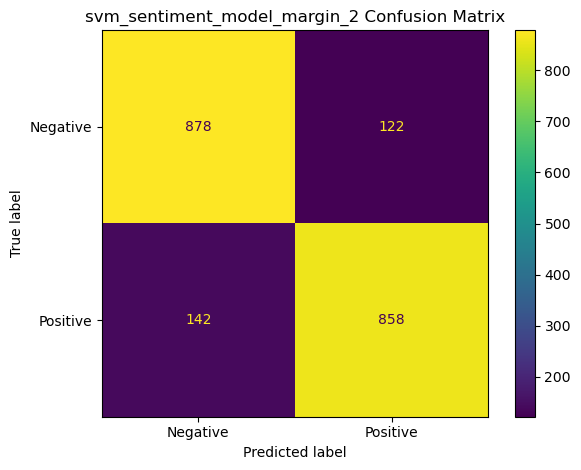

In [6]:
from config import MODEL_NAME


cm = confusion_matrix(
    test_labels,
    svm_predictions
)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title(f"{MODEL_NAME} Confusion Matrix")

plt.tight_layout()

plt.savefig(
    f"./experiments/{MODEL_NAME}_cm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [7]:
cm

array([[878, 122],
       [142, 858]], dtype=int64)

In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        svm_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87      1000
    Positive       0.88      0.86      0.87      1000

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



In [9]:
from config import MODEL_NAME

with open(f"./logs/[{MODEL_NAME}]_log.txt", "a") as f:    
    f.write(f"""\n\n
====================
Testing
====================

Accuracy: {accuracy * 100:.2f}%\n
Confusion Matrix:\n{cm}\n

""")

print("Accuracy added to experiment file")

Accuracy added to experiment file
